In [2]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset, WeightedRandomSampler
import math
import scipy.special
import random as rd
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.preprocessing import *

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


### Loading cifar-10 dataset

In [3]:
# Define transforms for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) # imageNet stats by rgb channel

# Load full training set (50,000 samples)
full_train_dataset = datasets.CIFAR10(root="C:/Users/Emilien JEMELEN/Documents/CIFAR/cifar_data", train=True, transform=transform, download=True)
# Load official test set (10,000 samples)
official_test_dataset = datasets.CIFAR10(root="C:/Users/Emilien JEMELEN/Documents/CIFAR/cifar_data", train=False, transform=transform, download=True)

# airplance = 1, not airplane = 0
binarize_labels(full_train_dataset)
binarize_labels(official_test_dataset)

In [4]:
full_train_dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [5]:
# Combine both datasets
combined_dataset = ConcatDataset([full_train_dataset, official_test_dataset])
# Total combined length
total_length = len(combined_dataset)
# Shuffle and split indices
indices = list(range(total_length))
rd.shuffle(indices)
# Split into train (for cnn training) and test (which will be training+test sets for Selective Prediction module)
train_indices = indices[:20000]
test_indices = indices[20000:]
# Create subsets
new_train_dataset = Subset(combined_dataset, train_indices)
new_test_dataset = Subset(combined_dataset, test_indices)
# get their associated labels from combined_dataset
train_labels = get_subset_labels(new_train_dataset, combined_dataset)
test_labels = get_subset_labels(new_test_dataset, combined_dataset)

# Create test dataloader (which will be training+test sets for Selective Prediction module)
test_loader = DataLoader(new_test_dataset, batch_size=6, shuffle=False)

# Create balanced samplers for training and validation of cnn
train_sampler = get_balanced_sampler(train_labels)
val_sampler = get_balanced_sampler(test_labels)
# Create DataLoaders using balanced samplers
train_loader = DataLoader(new_train_dataset, batch_size=6, sampler=train_sampler)
val_loader = DataLoader(new_test_dataset, batch_size=6, sampler=val_sampler)

## Training small CNN for cifar-2 classification task

In [9]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=20, kernel_size=4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=20, out_channels=32, kernel_size=4, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))  # Force feature map to 4x4
        self.fc1 = nn.Linear(32 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)             # Output shape: [B, 32, 4, 4]
        x = x.view(x.size(0), -1)             # Flatten safely: [B, 512]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model
cnn = SmallCNN().to(device)

In [11]:
# Define Loss, Optimizer and lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=0)
N_test = 1000

# Training Loop
num_epochs = 5
for epoch in range(num_epochs):
    cnn.train()
    running_loss = 0
    correct = 0
    total = 0

    print('TRAINING EPOCH', epoch)
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100 * correct / total:.2f}%")

    # Evaluate cnn at the end of current epoch
    cnn.eval()
    correct = 0
    total = 0
    print('TESTING')
    c = 0
    with torch.no_grad():
        for images, labels in val_loader:
            if c == N_test:
                break
            images, labels = images.to(device), labels.to(device)
            outputs = cnn(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            c += 1
            
    print(f"Test Accuracy: {100 * correct / total:.2f}%")
    scheduler.step(correct)

    torch.save(cnn.state_dict(), "C:/Users/Emilien JEMELEN/Documents/CIFAR/cnn_cifar_binary_epoch"+str(epoch)+".pth")

TRAINING EPOCH 0


100%|██████████| 3334/3334 [08:23<00:00,  6.62it/s]


Epoch [1/5], Loss: 0.5196
Train Accuracy: 75.39%
TESTING
Test Accuracy: 77.53%
TRAINING EPOCH 1


100%|██████████| 3334/3334 [09:37<00:00,  5.77it/s]


Epoch [2/5], Loss: 0.4610
Train Accuracy: 78.69%
TESTING
Test Accuracy: 79.90%
TRAINING EPOCH 2


100%|██████████| 3334/3334 [09:12<00:00,  6.04it/s]


Epoch [3/5], Loss: 0.4375
Train Accuracy: 79.83%
TESTING
Test Accuracy: 79.92%
TRAINING EPOCH 3


  4%|▍         | 126/3334 [00:20<08:48,  6.07it/s]


KeyboardInterrupt: 

Epoch 2 with 80% test accuracy is enough (model still has to commit mistakes otherwise SGR is not useful)

### Retrieving Softmax Response, Predicted class and True class for all samples in CNN test set 

In [12]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load trained cnn
cnn = SmallCNN().to(device)
checkpoint = torch.load("C:/Users/Emilien JEMELEN/Documents/SGR/models_weights/cnn_cifar_binary_epoch2.pth", map_location=torch.device('cpu'))
cnn.load_state_dict(checkpoint)

<All keys matched successfully>

In [13]:
sgr_dico = prepare_sgr_dico(test_loader, model = cnn, device = device, T = 1)
sgr_set = pd.DataFrame(sgr_dico)
pickle.dump(sgr_set, open('sgr_set_cnn','wb'))

100%|██████████| 6667/6667 [08:56<00:00, 12.43it/s]


In [14]:
sgr_set.sort_values('kappa')

,y_true,y_pred,kappa
39486,0.0,1.0,0.500018
21136,0.0,0.0,0.500021
4705,0.0,1.0,0.500034
16864,0.0,0.0,0.500078
34477,0.0,0.0,0.500084
...,...,...,...
26307,0.0,0.0,0.999042
18309,0.0,0.0,0.999132
20193,0.0,0.0,0.999147
17435,0.0,0.0,0.999519


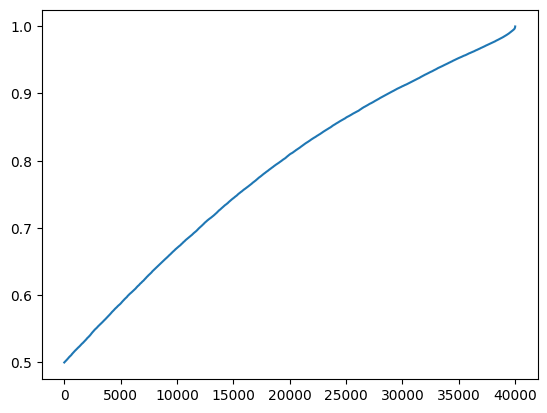

In [15]:
plt.plot(list(sgr_set.sort_values('kappa').kappa))
plt.show()

## MC dropout estimate of the variance in class 1 predicted logit, for each sample in test_loader

In [16]:
old_fc = cnn.fc1                       # this is your trained Linear(num_ftrs, 2)
cnn.fc1 = nn.Sequential(
    nn.Dropout(p=0.5),                  # pick p in [0.2, 0.6] typically
    old_fc
)

In [17]:
@torch.no_grad()
def mc_dropout_logits_variance(model, test_loader, device, T=50, class_idx=1, use_unbiased_var=False):
    model = model.to(device)

    # enable dropout but freeze BatchNorm stats
    model.train()

    cols = []
    for _ in range(T):
        batch_vals = []
        for xb, _ in tqdm(test_loader):
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)                 # [B, C]
            batch_vals.append(logits[:, class_idx].detach().cpu())
        cols.append(torch.cat(batch_vals, 0))

    mat = torch.stack(cols, 1)                 # [N, T]
    means = mat.mean(1)                        # [N]
    variances = mat.var(1, unbiased=use_unbiased_var)  # [N]
    return variances, means

In [32]:
# usage
var1, _ = mc_dropout_logits_variance(cnn, test_loader, device, T=10, class_idx=1)

100%|██████████| 6667/6667 [09:02<00:00, 12.28it/s]


In [61]:
var1.numpy()

array([0.20878828, 0.05712826, 0.31751162, ..., 0.21213919, 0.15903798,
       0.42421874], shape=(40000,), dtype=float32)